# Aspect-based evaluation with ModelRadar

Aggregate error (mean SMAPE over all series and horizons) hides where a model fails. **ModelRadar** slices a Nixtla-style cross-validation frame by overall score, unique ID, forecast horizon, hard series, ROPE, anomalies, and statistical groups such as stationarity and heteroskedasticity.

This notebook follows the **NeuralForecast** / **StatsForecast** workflow from [Nixtla](https://github.com/Nixtla/neuralforecast). Data is a long DataFrame with `unique_id`, `ds`, and `y`. Models are scored with `NeuralForecast.cross_validation` and `StatsForecast.cross_validation`. `ModelRadar` from `metaforecast.evaluation.aspects` sits on top of that CV frame.

Cerqueira, V., Roque, L., and Soares, C. (2025). Modelradar: aspect-based forecast evaluation. *Machine Learning*, 114(10), 229.

The steps are as follows.

1. Load M3 monthly and hold out the last 12 months of each series.
2. Cross-validate NHITS, KAN, two MLPs, and SeasonalNaive on the training set.
3. Flag anomalies from SeasonalNaive 99% prediction intervals and tag stationarity and heteroskedasticity.
4. Score models overall, by horizon, on hard series, and on anomalies.
5. Compare models with ROPE and seaborn plots across those aspects.


In [10]:
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

If necessary, install the package using pip:


In [11]:
# !pip install metaforecast datasetsforecast

## 1. Data preparation

This tutorial uses the M3 monthly dataset from `datasetsforecast` (1,428 series). Horizon and input size (lags) are both 12 months.

`SeriesWiseSplit.time_wise_split` keeps the last `horizon` observations of each series as the test set. Cross-validation below runs on the **training** set only, so the held-out window is not used to rank models here.


In [14]:
import pandas as pd
from datasetsforecast.m3 import M3

from metaforecast.evaluation.cv import SeriesWiseSplit

horizon, input_size = 12, 12

ds, *_ = M3.load(".", group="Monthly")
train_df, test_df = SeriesWiseSplit.time_wise_split(ds, horizon=horizon)

print(f"{train_df['unique_id'].nunique()} series")
train_df.head()

1428 series


,unique_id,ds,y
0,M1,1990-01-31,2640.0
1,M1,1990-02-28,2640.0
2,M1,1990-03-31,2160.0
3,M1,1990-04-30,4200.0
4,M1,1990-05-31,3360.0


## 2. Cross-validation

The comparison set is four neural networks from `neuralforecast` plus SeasonalNaive from `statsforecast`. Two rolling windows on the training set produce the CV frame that ModelRadar will slice.

SeasonalNaive is also fit with 99% prediction intervals. Those intervals are used in the next section to mark anomalous observations.


In [33]:
from neuralforecast import NeuralForecast
from neuralforecast.models import KAN, MLP, NHITS, NBEATS, PatchTST
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

CONFIG = {
    "input_size": input_size,
    "h": horizon,
    "accelerator": "mps",
    "max_steps": 500,
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "logger": False,
}

models = [
    NHITS(**CONFIG),
    NBEATS(**CONFIG),
    PatchTST(**CONFIG),
    KAN(**CONFIG),
    MLP(**CONFIG),
    MLP(num_layers=3, **CONFIG),
]

nf = NeuralForecast(models=models, freq="ME")
sf = StatsForecast(models=[SeasonalNaive(season_length=12)], freq="ME", n_jobs=1)

cv_nf = nf.cross_validation(df=train_df, n_windows=2)
cv_sf = sf.cross_validation(df=train_df, h=horizon, level=[99])

for frame in (cv_nf, cv_sf):
    if "unique_id" not in frame.columns:
        frame.reset_index(inplace=True)

cv = cv_nf.merge(cv_sf.drop(columns="y"), on=["unique_id", "ds", "cutoff"])
cv.head()

Seed set to 1


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


,unique_id,ds,cutoff,NHITS,NBEATS,PatchTST,KAN,MLP,MLP1,y,SeasonalNaive,SeasonalNaive-lo-99,SeasonalNaive-hi-99
0,M1,1993-09-30,1993-08-31,2739.991455,2630.994385,2858.758057,2455.264893,2510.048828,2497.915283,4800.0,6720.0,-1538.656675,14978.656675
1,M1,1993-10-31,1993-08-31,2558.178711,2234.293945,2313.489014,1996.415527,2203.545654,2154.128906,3000.0,2040.0,-6218.656675,10298.656675
2,M1,1993-11-30,1993-08-31,2593.944336,2642.384033,3110.632568,3101.276123,3060.470703,2468.546143,3120.0,6480.0,-1778.656675,14738.656675
3,M1,1993-12-31,1993-08-31,2235.054443,1979.944702,2092.229980,1742.440063,2058.392822,2043.339844,5880.0,1920.0,-6338.656675,10178.656675
4,M1,1994-01-31,1993-08-31,2358.973877,2321.739746,2427.277344,2144.668945,2206.437256,2164.236572,2640.0,3600.0,-4658.656675,11858.656675


## 3. Anomalies and series aspects

An observation is treated as anomalous if it falls outside the SeasonalNaive 99% interval. Stationarity (KPSS via `DifferencingTests.ndiffs`) and heteroskedasticity (Breusch-Pagan) are computed on each training series and mapped onto the CV frame. Those columns are later passed to `evaluate_by_group`.


In [34]:
from metaforecast.evaluation.aspects._stationarity import DifferencingTests
from metaforecast.evaluation.aspects._heteroskedasticity import Heteroskedasticity

is_outside_pi = (cv["y"] >= cv["SeasonalNaive-hi-99"]) | (
    cv["y"] <= cv["SeasonalNaive-lo-99"]
)
cv["is_anomaly"] = is_outside_pi.astype(int)
cv["anomaly_status"] = cv["is_anomaly"].map({0: "Non-anomalies", 1: "Anomalies"})

stationarity_labels = {}
het_labels = {}
for uid, uid_df in train_df.groupby("unique_id"):
    y = uid_df["y"]
    ndiffs = DifferencingTests.ndiffs(y, test="kpss")
    stationarity_labels[uid] = "Stationary" if ndiffs == 0 else "Non-stationary"
    bp_pvalue = Heteroskedasticity.het_tests(y, test="Breusch-Pagan")
    het_labels[uid] = "Heteroskedastic" if bp_pvalue < 0.05 else "Homoskedastic"

cv["stationarity"] = cv["unique_id"].map(stationarity_labels)
cv["heteroskedasticity"] = cv["unique_id"].map(het_labels)

print(cv["is_anomaly"].mean().round(3), "share of anomalous observations")
cv[["unique_id", "stationarity", "heteroskedasticity"]].drop_duplicates().head()


0.023 share of anomalous observations


,unique_id,stationarity,heteroskedasticity
0,M1,Non-stationary,Homoskedastic
12,M10,Stationary,Homoskedastic
24,M100,Non-stationary,Homoskedastic
36,M1000,Non-stationary,Heteroskedastic
48,M1001,Non-stationary,Homoskedastic


## 4. Fit ModelRadar

`hardness_reference` defines hard series (those where SeasonalNaive is worst). `ratios_reference` is the ROPE champion. Scores below use SMAPE.


In [36]:
from utilsforecast.losses import smape

from metaforecast.evaluation.aspects import ModelRadar

MODEL_NAMES = ["NHITS", "NBEATS", "PatchTST", "KAN", "MLP", "MLP1", "SeasonalNaive"]

radar = ModelRadar(
    cv_df=cv,
    metrics=[smape],
    model_names=MODEL_NAMES,
    hardness_reference="SeasonalNaive",
    ratios_reference="NHITS",
    rope=10,
)
radar.model_order

['NBEATS', 'NHITS', 'MLP', 'KAN', 'MLP1', 'PatchTST', 'SeasonalNaive']

In [37]:
overall = radar.evaluate()
err = radar.evaluate(keep_uids=True)

display(overall.to_frame("Overall"))
err.head()

,Overall
NHITS,0.064757
NBEATS,0.063943
PatchTST,0.068095
KAN,0.067452
MLP,0.066433
MLP1,0.067568
SeasonalNaive,0.078550


,NHITS,NBEATS,PatchTST,KAN,MLP,MLP1,SeasonalNaive
unique_id,,,,,,,
M1,0.215037,0.239656,0.228291,0.256810,0.232643,0.250528,0.282303
M10,0.125788,0.101310,0.107539,0.125759,0.113001,0.108098,0.162743
M100,0.046382,0.043647,0.040990,0.041595,0.042623,0.039678,0.058894
M1000,0.006705,0.005880,0.011539,0.012427,0.008615,0.011289,0.016061
M1001,0.014464,0.015240,0.017999,0.020737,0.013574,0.011603,0.017680


Plot helpers used in the rest of the notebook. Lower SMAPE is better in every bar and line plot.


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
ORDER = radar.model_order
PALETTE = dict(zip(ORDER, sns.color_palette("viridis", n_colors=len(ORDER))))


def barh_scores(scores, title, xlabel="SMAPE"):
    s = scores.reindex(ORDER) if set(ORDER) <= set(scores.index) else scores.sort_values()
    plot_df = s.rename("score").reset_index()
    plot_df.columns = ["model", "score"]
    fig, ax = plt.subplots(figsize=(8, 3.6))
    sns.barplot(
        data=plot_df,
        y="model",
        x="score",
        hue="model",
        palette=PALETTE,
        dodge=False,
        ax=ax,
        order=[m for m in ORDER if m in set(plot_df["model"])],
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()


def grouped_bars(df, title, xlabel="SMAPE"):
    long = df.loc[ORDER].reset_index().melt(id_vars=df.index.name or "index")
    long.columns = ["model", "group", "score"]
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=long, x="model", y="score", hue="group", order=ORDER, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(xlabel)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="")
    fig.tight_layout()
    plt.show()


def stacked_rope(rope_df, title):
    fig, ax = plt.subplots(figsize=(8, 3.6))
    rope_df.loc[[m for m in ORDER if m in rope_df.index]].plot(
        kind="barh", stacked=True, ax=ax, colormap="Set2"
    )
    ax.set_title(title)
    ax.set_xlabel("Share of series")
    ax.set_ylabel("")
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()



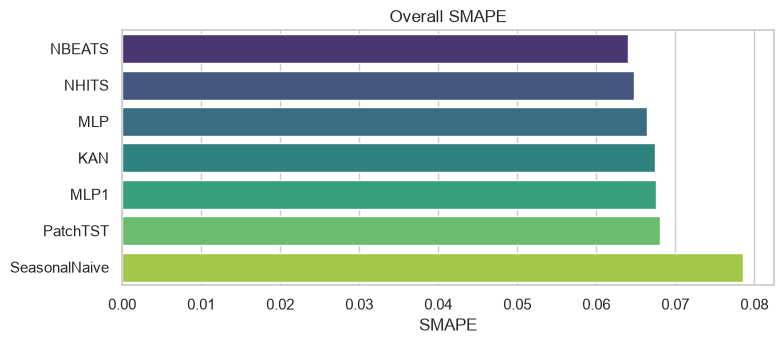

In [39]:
barh_scores(overall, "Overall SMAPE")

## 5. Hard series and expected shortfall

Hard unique IDs are those where SeasonalNaive exceeds its 90th-percentile error. Expected shortfall is the mean error in each model's own worst tail.


In [40]:
hard = radar.uid_accuracy.get_hard_uids(err)
print("n hard uids:", len(radar.uid_accuracy.hard_uid))

summary = pd.concat(
    [
        overall,
        radar.uid_accuracy.accuracy_on_hard(err),
        radar.uid_accuracy.expected_shortfall(err),
    ],
    axis=1,
)
summary

n hard uids: 143


,Overall,On Hard,Exp. Shortfall
NHITS,0.064757,0.204411,0.261850
NBEATS,0.063943,0.204569,0.257630
PatchTST,0.068095,0.207344,0.270894
KAN,0.067452,0.212634,0.270170
MLP,0.066433,0.205465,0.255579
MLP1,0.067568,0.204134,0.255232
SeasonalNaive,0.078550,0.254086,0.302257


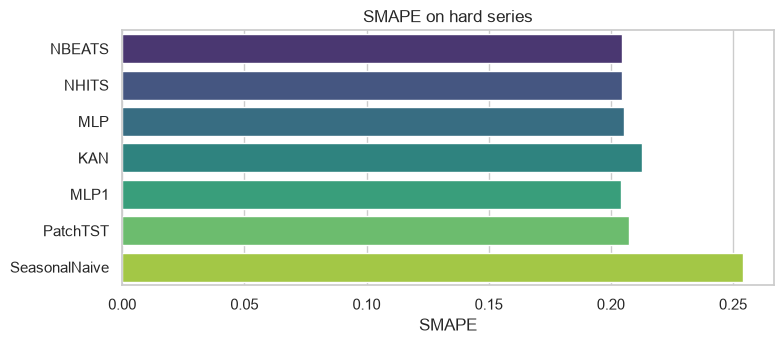

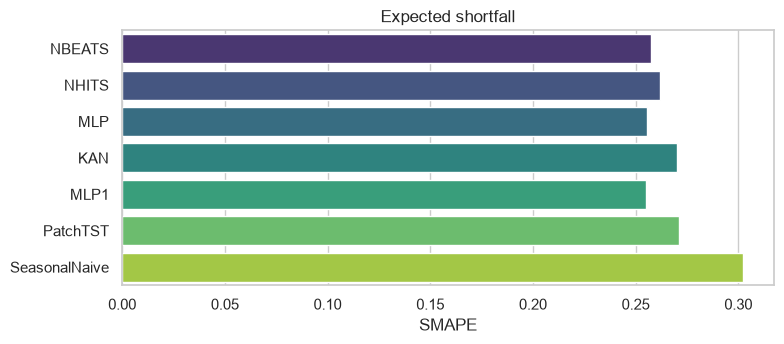

In [41]:
barh_scores(radar.uid_accuracy.accuracy_on_hard(err), "SMAPE on hard series")
barh_scores(radar.uid_accuracy.expected_shortfall(err), "Expected shortfall")

## 6. Horizon

First-step vs last-step error, then SMAPE accumulated up to each horizon. A model that wins overall can still lose on multi-step forecasts.


In [42]:
eval_hbounds = radar.evaluate_by_horizon_bounds()
eval_hbounds

,First horizon,Last horizon
Model,,
NHITS,0.056870,0.074021
NBEATS,0.056188,0.074024
PatchTST,0.060421,0.077101
KAN,0.060883,0.075812
MLP,0.064771,0.073416
MLP1,0.069075,0.074954
SeasonalNaive,0.086530,0.080610


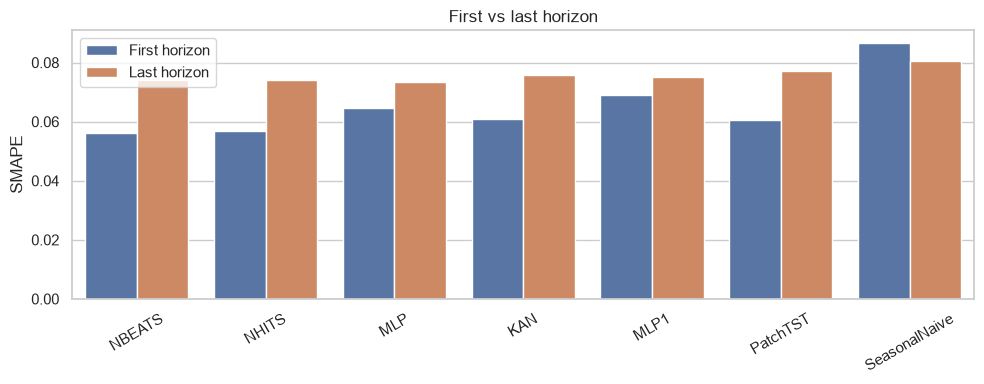

In [43]:
grouped_bars(eval_hbounds, "First vs last horizon")

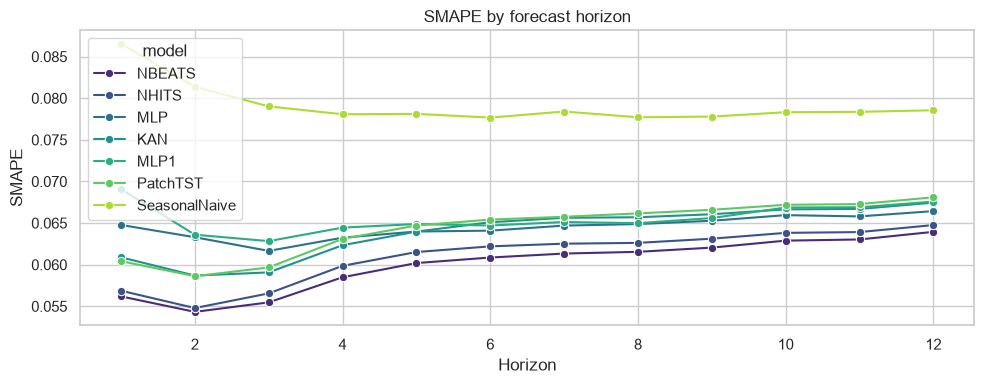

In [44]:
eval_fhorizon = radar.evaluate_by_horizon()
long_h = eval_fhorizon.melt(id_vars="horizon", var_name="model", value_name="SMAPE")
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=long_h,
    x="horizon",
    y="SMAPE",
    hue="model",
    hue_order=ORDER,
    palette=PALETTE,
    marker="o",
    ax=ax,
)
ax.set_title("SMAPE by forecast horizon")
ax.set_xlabel("Horizon")
fig.tight_layout()
plt.show()

## 7. ROPE win / draw / loss

ROPE reports the share of series where each model beats, draws, or loses to NHITS by more than 10 percent. The second plot repeats the comparison on hard series only.


,NHITS loses,draw,NHITS wins
NBEATS,0.207283,0.687675,0.105042
PatchTST,0.135854,0.463585,0.400560
KAN,0.140056,0.479692,0.380252
MLP,0.199580,0.403361,0.397059
MLP1,0.240896,0.334734,0.424370
SeasonalNaive,0.161765,0.194678,0.643557


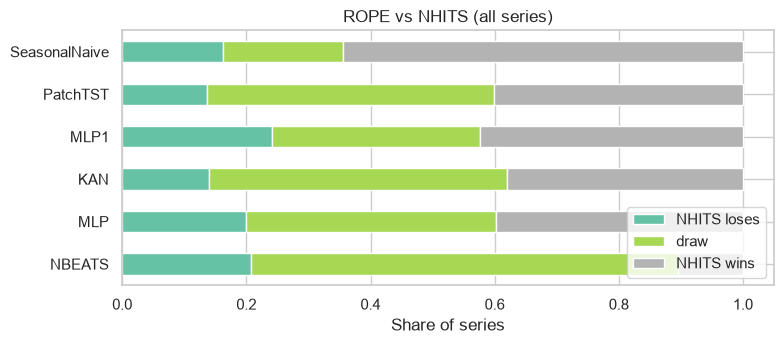

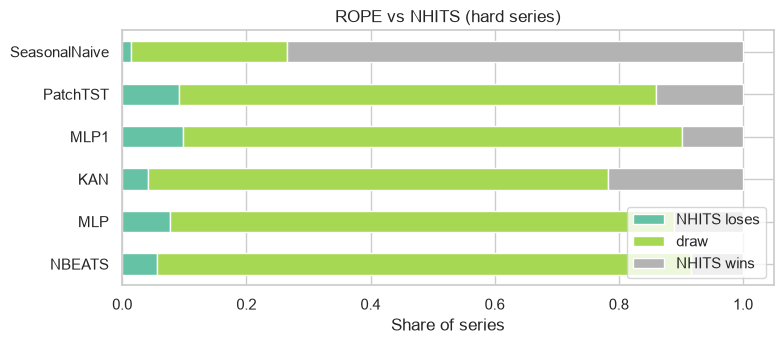

In [45]:
rope_all = radar.rope.get_winning_ratios(err)
rope_hard = radar.rope.get_winning_ratios(hard)
display(rope_all)
stacked_rope(rope_all, "ROPE vs NHITS (all series)")
stacked_rope(rope_hard, "ROPE vs NHITS (hard series)")

## 8. Groups: anomalies, stationarity, heteroskedasticity

`evaluate_by_group` scores models within each level of a categorical column. Anomalies use the interval flag from Section 3. Stationarity and heteroskedasticity use the KPSS and Breusch-Pagan labels.


,Anomalies,Non-anomalies
NHITS,0.191822,0.062603
NBEATS,0.192743,0.061798
PatchTST,0.189169,0.066201
KAN,0.201976,0.065143
MLP,0.192510,0.064247
MLP1,0.184152,0.065528
SeasonalNaive,0.262822,0.075220


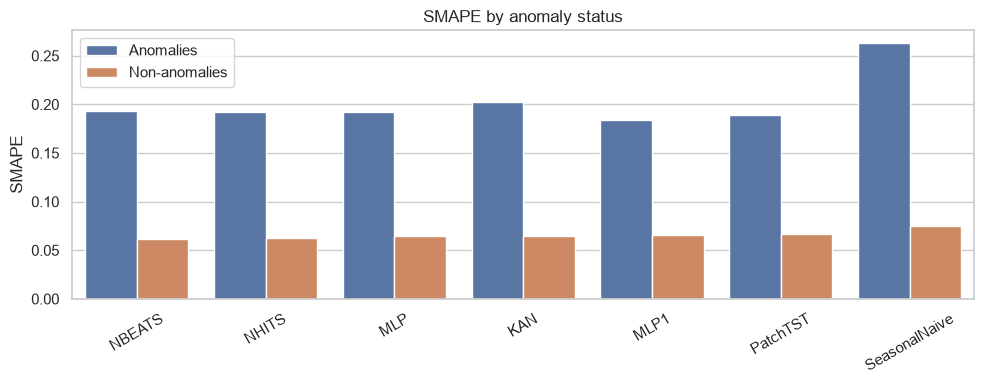

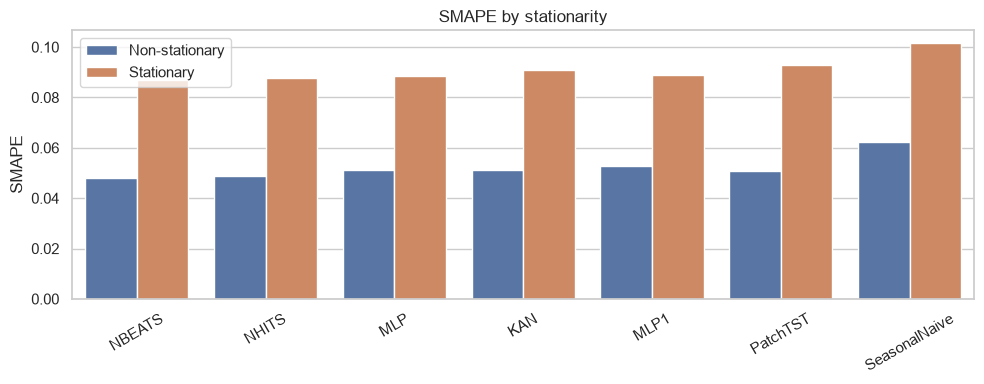

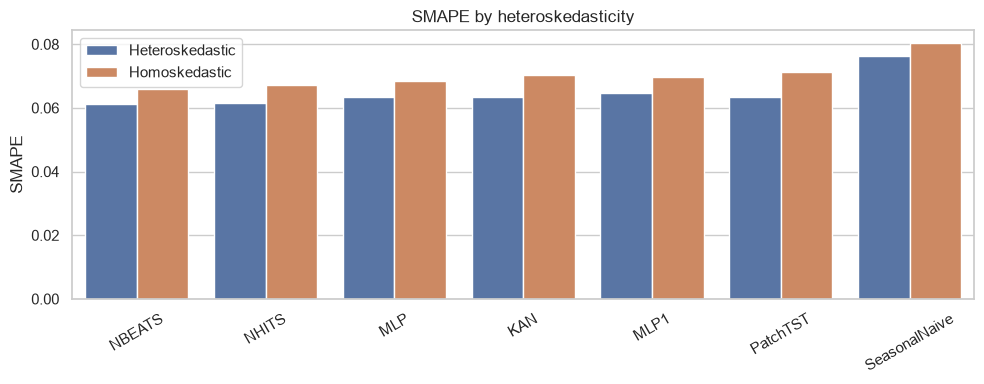

In [46]:
error_on_anomalies = radar.evaluate_by_group("anomaly_status")
error_on_stat = radar.evaluate_by_group("stationarity")
error_on_het = radar.evaluate_by_group("heteroskedasticity")

display(error_on_anomalies)
grouped_bars(error_on_anomalies, "SMAPE by anomaly status")
grouped_bars(error_on_stat, "SMAPE by stationarity")
grouped_bars(error_on_het, "SMAPE by heteroskedasticity")

series with at least one anomaly: 174


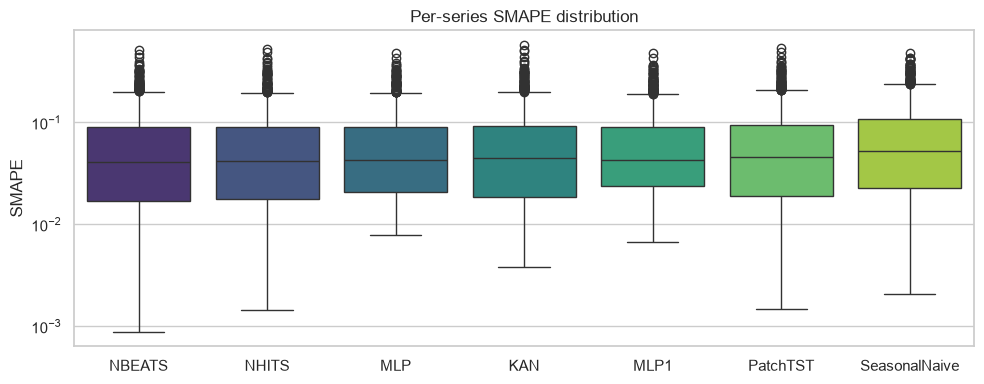

In [47]:
err_anomalies = radar.evaluate_by_anomaly(mode="observations")
print("series with at least one anomaly:", 0 if err_anomalies is None else len(err_anomalies))

long_err = err[ORDER].melt(var_name="model", value_name="SMAPE")
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=long_err,
    x="model",
    y="SMAPE",
    hue="model",
    order=ORDER,
    palette=PALETTE,
    legend=False,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Per-series SMAPE distribution")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

## 9. Multi-aspect summary

Concatenate the aspect scores and draw parallel-coordinate and spider plots. **normalize** rescales each column to \([0, 1]\) (0 = best). **rank** assigns 1 to the lowest error.


In [48]:
df_plot = pd.concat(
    [
        overall,
        radar.uid_accuracy.expected_shortfall(err),
        eval_hbounds,
        radar.uid_accuracy.accuracy_on_hard(err),
        error_on_anomalies,
        error_on_stat,
        error_on_het,
    ],
    axis=1,
)
df_plot


,Overall,Exp. Shortfall,First horizon,Last horizon,On Hard,Anomalies,Non-anomalies,Non-stationary,Stationary,Heteroskedastic,Homoskedastic
NHITS,0.064757,0.261850,0.056870,0.074021,0.204411,0.191822,0.062603,0.048644,0.087777,0.061627,0.067046
NBEATS,0.063943,0.257630,0.056188,0.074024,0.204569,0.192743,0.061798,0.047840,0.086948,0.061116,0.066009
PatchTST,0.068095,0.270894,0.060421,0.077101,0.207344,0.189169,0.066201,0.050765,0.092853,0.063571,0.071402
KAN,0.067452,0.270170,0.060883,0.075812,0.212634,0.201976,0.065143,0.051115,0.090792,0.063459,0.070371
MLP,0.066433,0.255579,0.064771,0.073416,0.205465,0.192510,0.064247,0.051095,0.088344,0.063519,0.068563
MLP1,0.067568,0.255232,0.069075,0.074954,0.204134,0.184152,0.065528,0.052723,0.088776,0.064771,0.069613
SeasonalNaive,0.078550,0.302257,0.086530,0.080610,0.254086,0.262822,0.075220,0.062484,0.101501,0.076146,0.080307


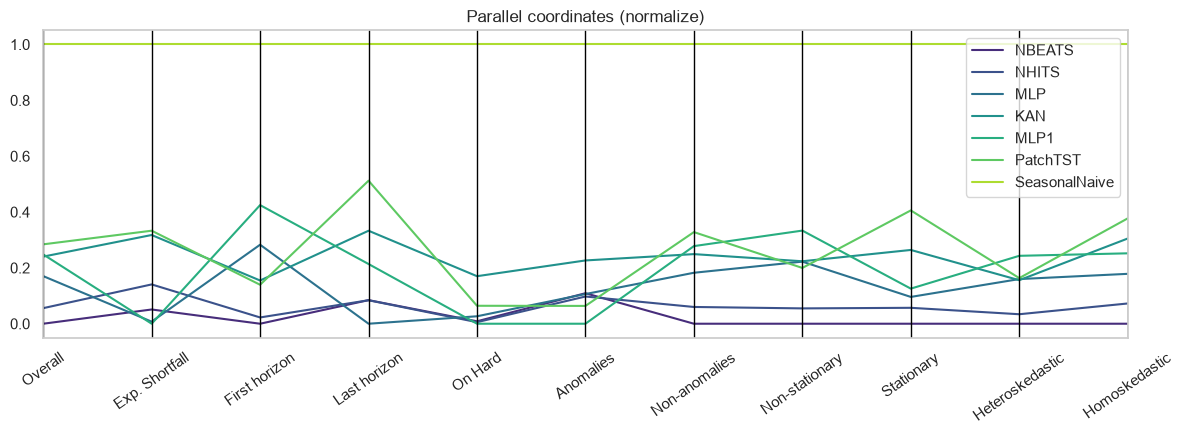

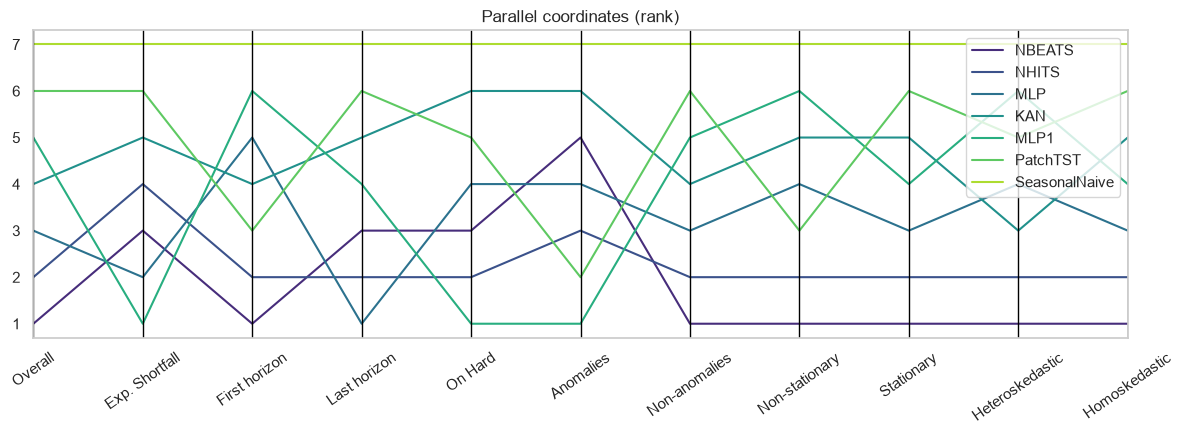

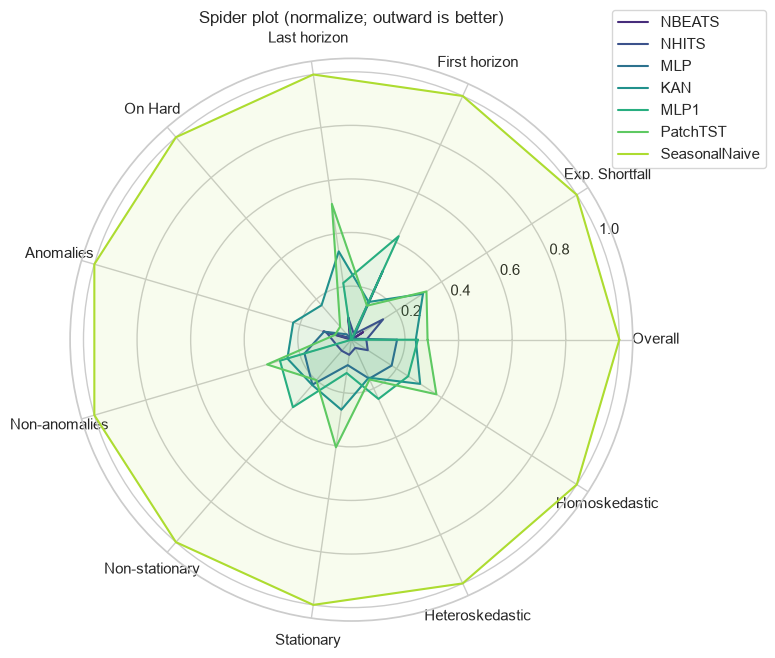

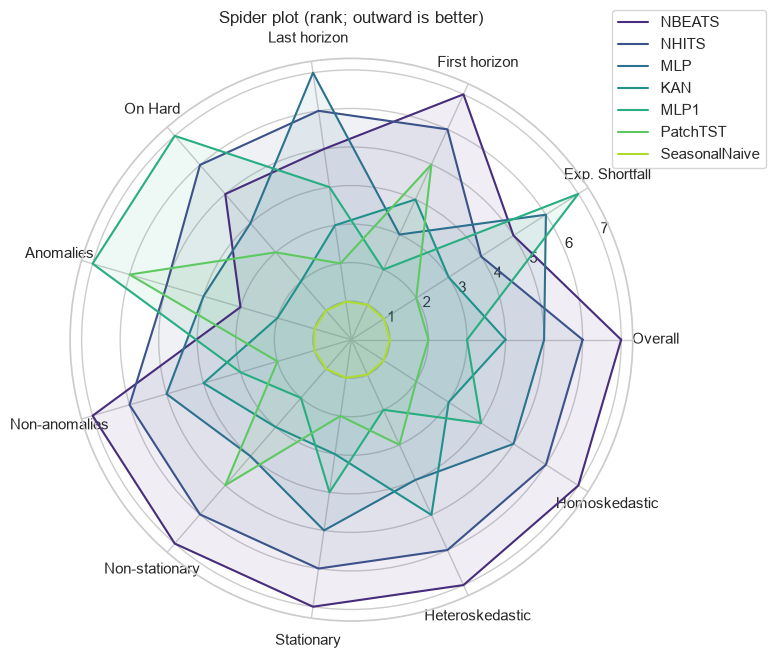

In [49]:
from pandas.plotting import parallel_coordinates


def aspect_view(df, values):
    if values == "rank":
        return df.rank(axis=0, method="average", ascending=True)
    scaled = (df - df.min()) / (df.max() - df.min())
    return scaled.fillna(0)


def plot_parallel(df, values):
    view = aspect_view(df, values).loc[ORDER].reset_index()
    view = view.rename(columns={view.columns[0]: "model"})
    fig, ax = plt.subplots(figsize=(12, 4.5))
    parallel_coordinates(view, "model", color=[PALETTE[m] for m in view["model"]], ax=ax)
    ax.set_title(f"Parallel coordinates ({values})")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()


def plot_spider(df, values):
    view = aspect_view(df, values).loc[ORDER]
    if values == "rank":
        view = view.max().max() + 1 - view
    cats = [str(c) for c in view.columns]
    angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
    for model, row in view.iterrows():
        vals = row.tolist() + [row.iloc[0]]
        ax.plot(angles, vals, label=model, color=PALETTE[model])
        ax.fill(angles, vals, color=PALETTE[model], alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats)
    ax.set_title(f"Spider plot ({values}; outward is better)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
    fig.tight_layout()
    plt.show()


plot_parallel(df_plot, "normalize")
plot_parallel(df_plot, "rank")
plot_spider(df_plot, "normalize")
plot_spider(df_plot, "rank")



A model can lead on mean SMAPE and still lose on hard series, long horizons, or heteroskedastic groups. That is the point of the aspect view: overall rank is not the same as rank on every slice.
